<a href="https://colab.research.google.com/github/viscp1011/farmtech-fase5-ml/blob/main/VitorioStevanatto_pbl_fase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FarmTech Solutions - Analise de Rendimento de Safras com Machine Learning
## FIAP - Fase 5 | PBL Cap 1

**Aluno:** Vitorio Stevanatto Compri Paciulo

---

### Objetivo
Analisar dados de solo e clima para prever rendimento de safras e identificar tendencias.

### Dataset crop_yield.csv
- **Crop**: Cultura agricola
- **Precipitation (mm day-1)**: Precipitacao
- **Specific Humidity at 2 Meters (g/kg)**: Umidade especifica
- **Relative Humidity at 2 Meters (%)**: Umidade relativa
- **Temperature at 2 Meters (C)**: Temperatura
- **Yield**: Rendimento (variavel alvo)

In [ ]:
ase64; content=open('/content/VitorioStevanatto_pbl_fase4.ipynb','rb').read(); print(base64.b64encode(content).decode()[:100])""

## 1. Importacao das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados

In [2]:
file_id = '169QVRrF_ID-IEWQU3pz-Lh0NPOkLmMi3'
url = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_csv(url)
print(f'Dataset carregado! Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
df.head(10)

Dataset carregado! Shape: (156, 6)
Colunas: ['Crop', 'Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
5,"Cocoa, beans",2339.30,17.70,84.54,25.76,8850
6,"Cocoa, beans",2326.09,18.09,84.63,26.11,9003
7,"Cocoa, beans",2718.08,18.30,85.43,26.12,9880
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300


## 3. Analise Exploratoria (EDA)

### 3.1 Informacoes Gerais

In [3]:
print('=== INFO ===')
df.info()
print('\n=== NULOS ===')
print(df.isnull().sum())
print('\n=== ESTATISTICAS ===')
df.describe()

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB

=== NULOS ===
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

=== 

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [4]:
print('=== CULTURAS ===')
print(df['Crop'].value_counts())
print(f'Total de culturas: {df["Crop"].nunique()}')

=== CULTURAS ===
Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64
Total de culturas: 4


### 3.2 Distribuicao das Variaveis

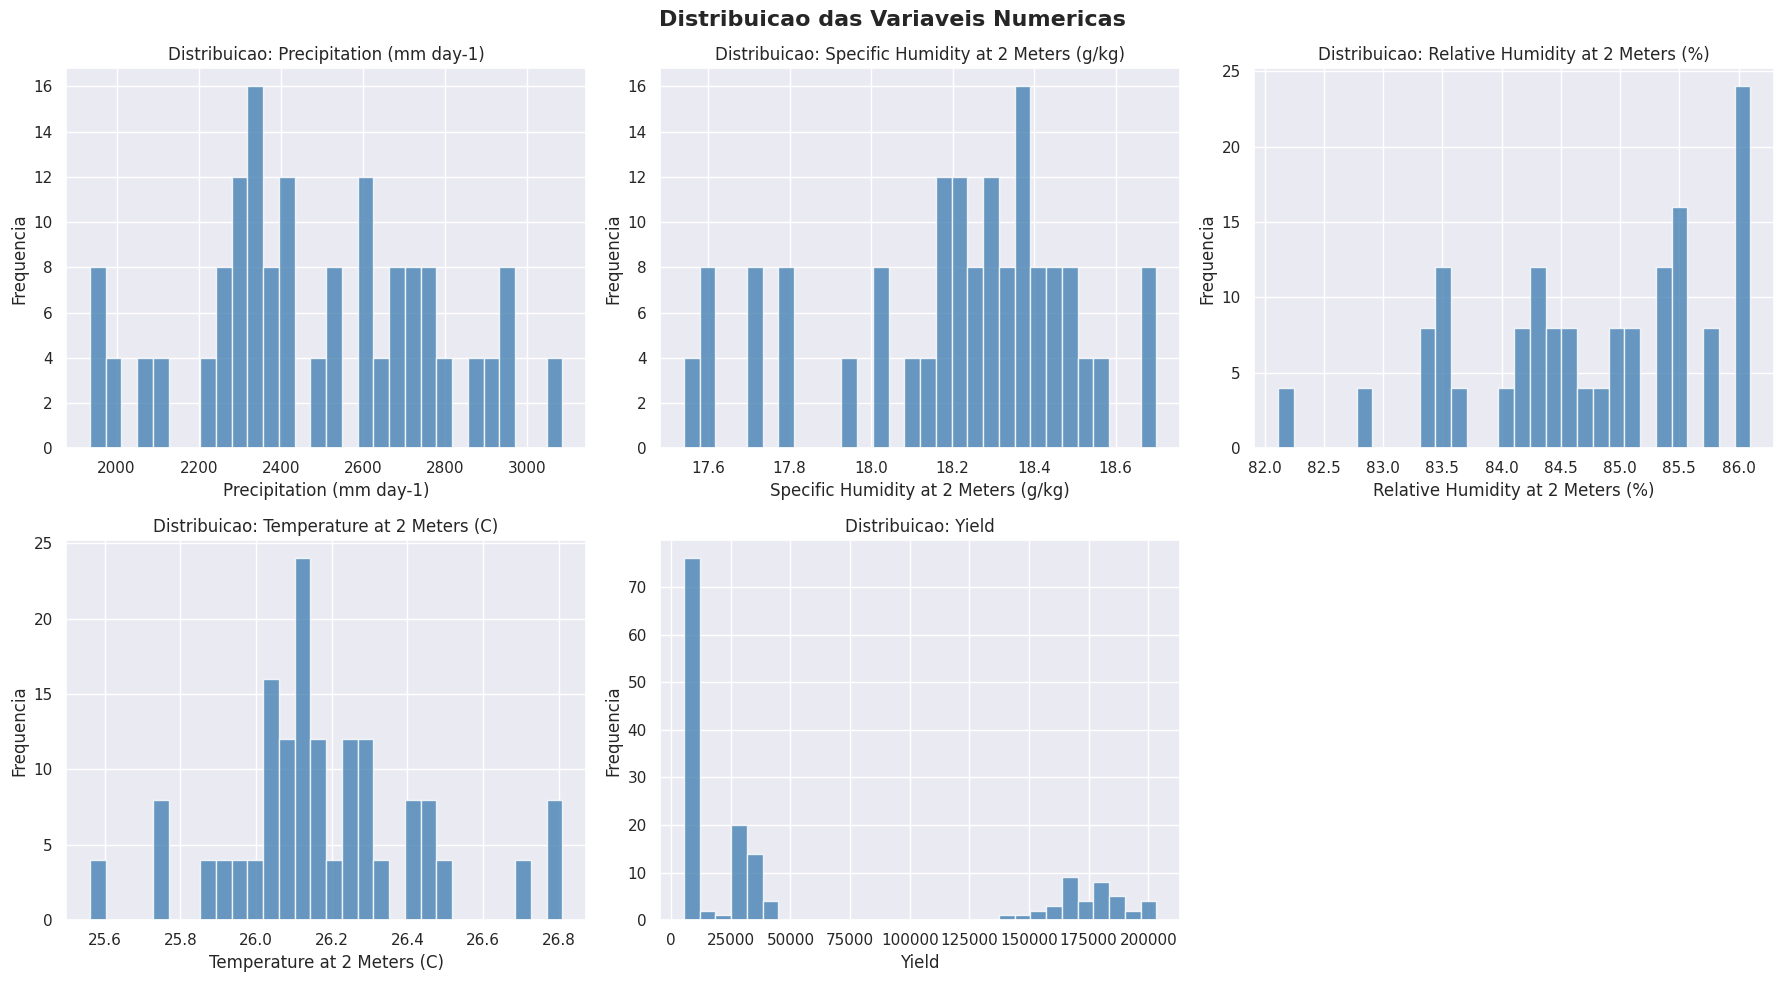

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribuicao: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequencia')
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribuicao das Variaveis Numericas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_183/2870476538.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Crop', y='Yield', palette='Set2')


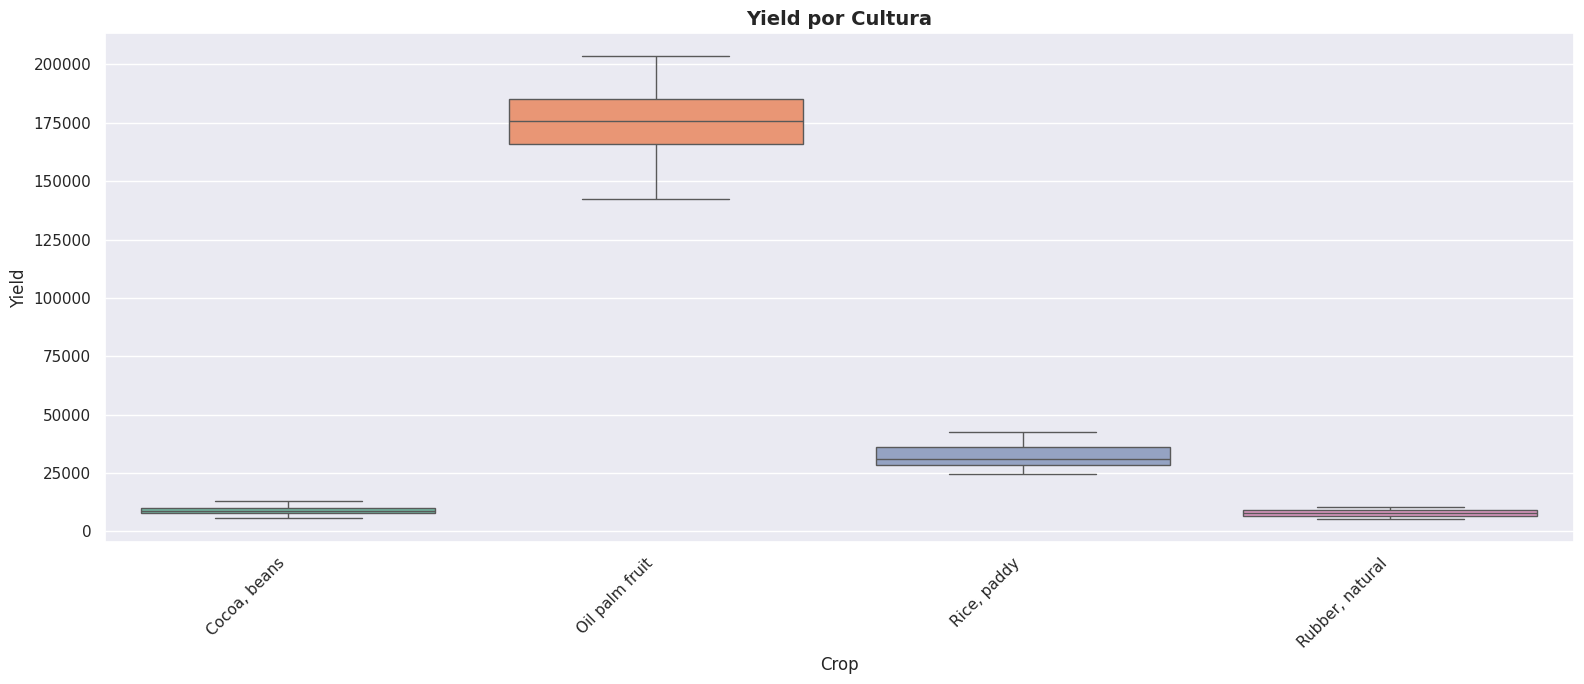

In [6]:
plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='Crop', y='Yield', palette='Set2')
plt.title('Yield por Cultura', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.3 Mapa de Correlacao

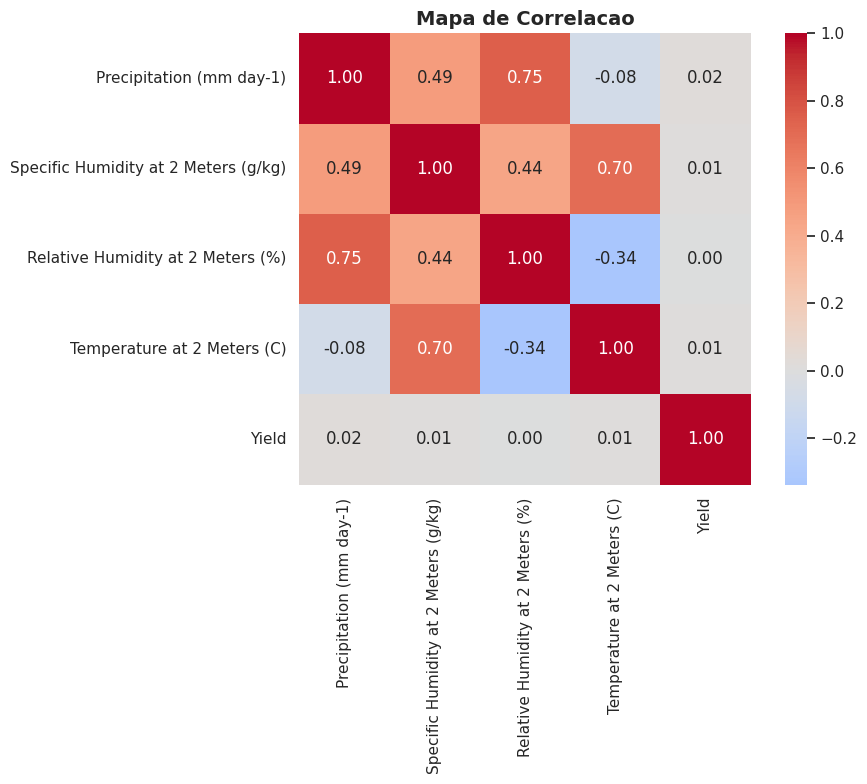

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Mapa de Correlacao', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Clusterizacao K-Means e Deteccao de Outliers

### 4.1 Pre-processamento

In [8]:
le = LabelEncoder()
df['Crop_encoded'] = le.fit_transform(df['Crop'])

features_cluster = ['Crop_encoded','Precipitation (mm day-1)','Specific Humidity at 2 Meters (g/kg)','Relative Humidity at 2 Meters (%)','Temperature at 2 Meters (C)']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_cluster])
print(f'Dados normalizados: {X_scaled.shape}')

Dados normalizados: (156, 5)


### 4.2 Metodo do Cotovelo

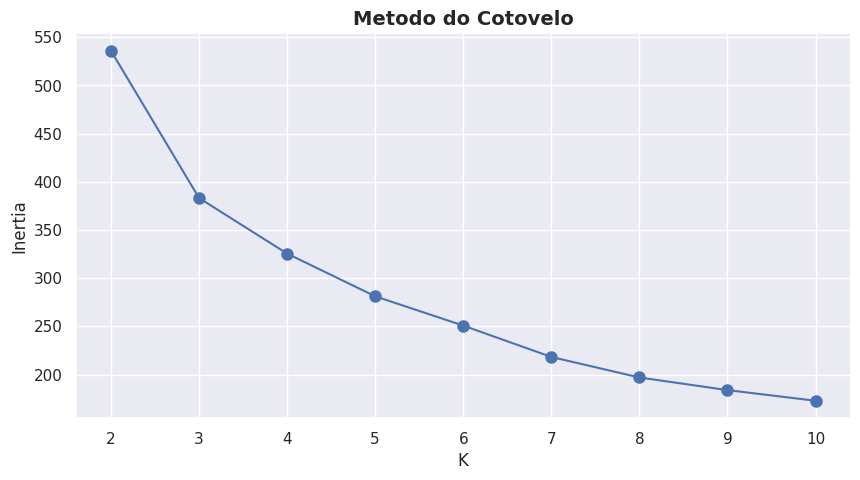

In [9]:
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
plt.figure(figsize=(10, 5))
plt.plot(range(2,11), inertias, 'bo-', markersize=8)
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Metodo do Cotovelo', fontsize=14, fontweight='bold')
plt.grid(True)
plt.show()

In [10]:
K_IDEAL = 4
kmeans = KMeans(n_clusters=K_IDEAL, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print(df['Cluster'].value_counts().sort_index())

Cluster
0    36
1    37
2    40
3    43
Name: count, dtype: int64


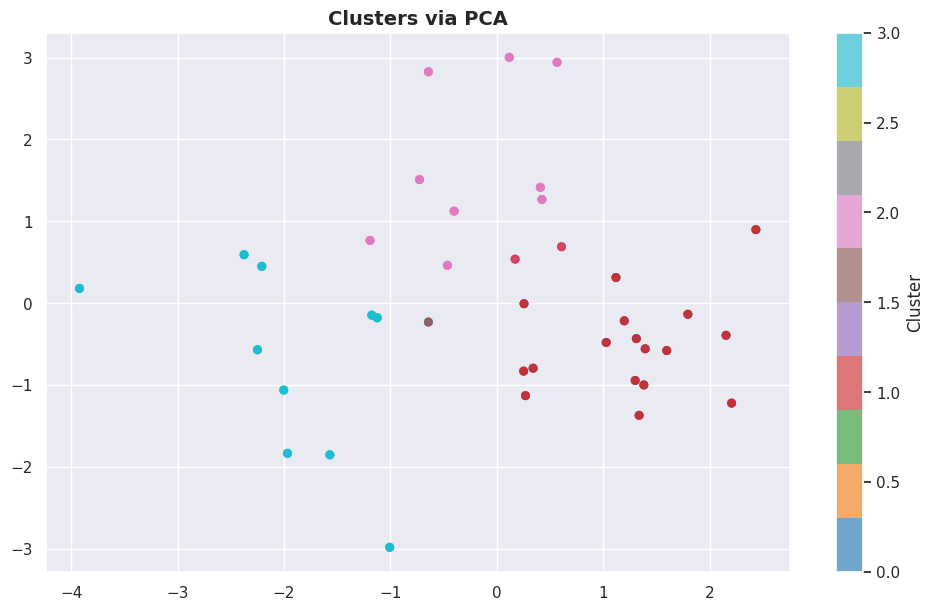

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['Cluster'] = df['Cluster'].values
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='tab10', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster')
plt.title('Clusters via PCA', fontsize=14, fontweight='bold')
plt.show()

### 4.3 Analise de Clusters e Outliers

In [12]:
print('=== YIELD POR CLUSTER ===')
print(df.groupby('Cluster')['Yield'].agg(['mean','std','min','max','count']).round(2))

Q1 = df['Yield'].quantile(0.25)
Q3 = df['Yield'].quantile(0.75)
IQR = Q3 - Q1
outp = df[(df['Yield'] < Q1-1.5*IQR)|(df['Yield'] > Q3+1.5*IQR)]
print(f'\nOutliers: {len(outp)} ({len(outp)/len(df)*100:.2f}%)')

=== YIELD POR CLUSTER ===
             mean       std   min     max  count
Cluster                                         
0        88268.39  85586.30  6530  199074     36
1        19531.73  12987.57  5249   37972     37
2        62399.15  74037.53  5571  203399     40
3        54967.00  69707.34  5765  201436     43

Outliers: 35 (22.44%)


## 5. Modelagem Preditiva: 5 Modelos de Regressao

### 5.1 Preparacao dos Dados

In [13]:
features = ['Crop_encoded','Precipitation (mm day-1)','Specific Humidity at 2 Meters (g/kg)','Relative Humidity at 2 Meters (%)','Temperature at 2 Meters (C)']
X = df[features].values
y = df['Yield'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_ml = StandardScaler()
X_train_s = scaler_ml.fit_transform(X_train)
X_test_s = scaler_ml.transform(X_test)
print(f'Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')

Treino: 124 | Teste: 32


### 5.2 Treinamento dos 5 Modelos

In [14]:
modelos = {
    '1. Regressao Linear': LinearRegression(),
    '2. Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    '3. Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    '4. Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    '5. SVR (RBF)': SVR(kernel='rbf', C=100, epsilon=0.1)
}
resultados = {}
print(f'{"Modelo":<30} {"MAE":>10} {"RMSE":>10} {"R2":>8}')
print('-'*60)
for nome, modelo in modelos.items():
    modelo.fit(X_train_s, y_train)
    y_pred = modelo.predict(X_test_s)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    resultados[nome] = {'MAE':mae,'RMSE':rmse,'R2':r2,'preds':y_pred}
    print(f'{nome:<30} {mae:>10.2f} {rmse:>10.2f} {r2:>8.4f}')

Modelo                                MAE       RMSE       R2
------------------------------------------------------------
1. Regressao Linear              53724.49   65364.57  -0.1015
2. Decision Tree                  2896.38    4888.37   0.9938
3. Random Forest                  2744.58    4656.11   0.9944
4. Gradient Boosting              3052.78    5176.01   0.9931
5. SVR (RBF)                     38837.31   71234.82  -0.3082


### 5.3 Comparacao das Metricas

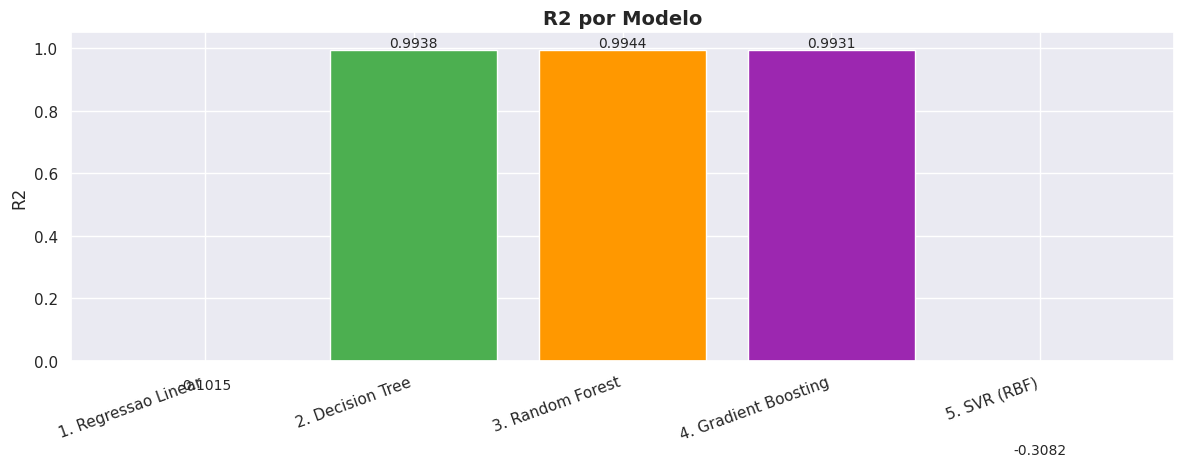

In [15]:
df_m = pd.DataFrame([{'Modelo':n,'MAE':v['MAE'],'RMSE':v['RMSE'],'R2':v['R2']} for n,v in resultados.items()])
cores = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
plt.figure(figsize=(12, 5))
bars = plt.bar(df_m['Modelo'], df_m['R2'], color=cores)
plt.title('R2 por Modelo', fontsize=14, fontweight='bold')
plt.ylabel('R2')
plt.ylim(0,1.05)
plt.xticks(rotation=20, ha='right')
for b,v in zip(bars,df_m['R2']): plt.text(b.get_x()+b.get_width()/2,b.get_height()+0.01,f'{v:.4f}',ha='center',fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_183/1073457939.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(df_m['Modelo'],rotation=20,ha='right')
/tmp/ipykernel_183/1073457939.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df_m['Modelo'],rotation=20,ha='right')


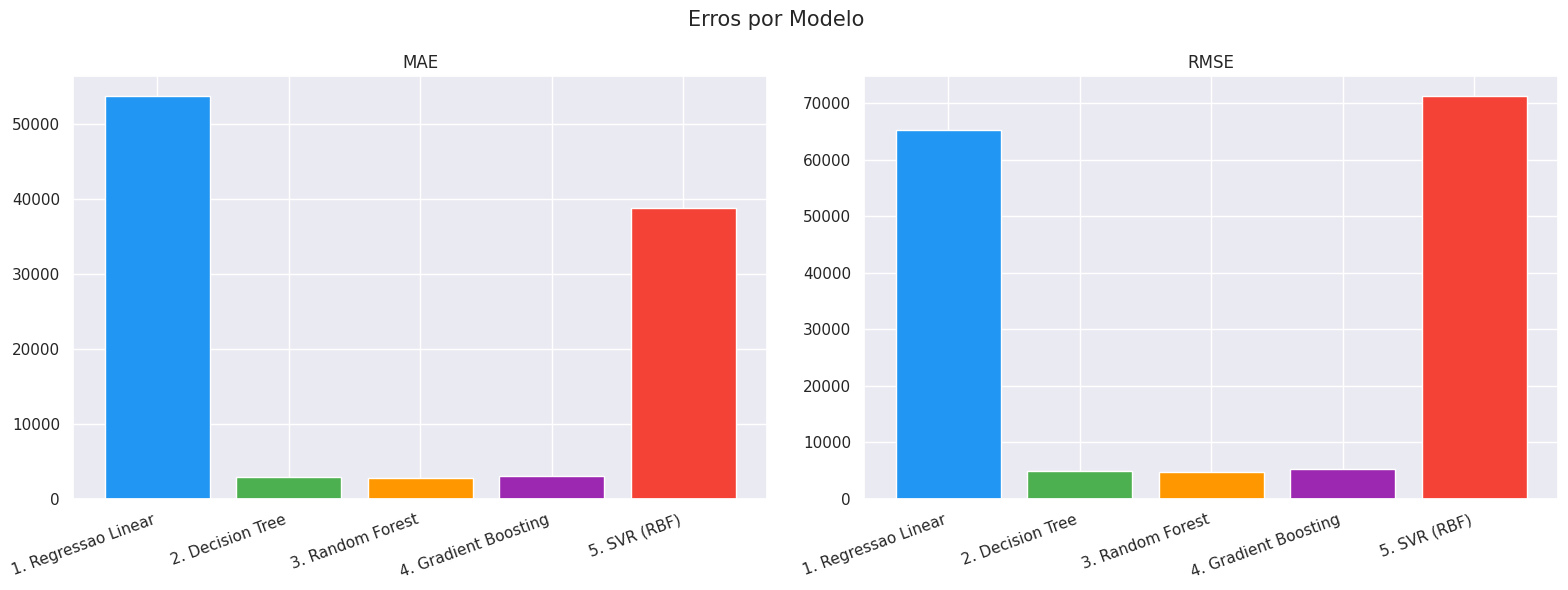

              Modelo          MAE         RMSE        R2
 1. Regressao Linear 53724.485077 65364.569016 -0.101459
    2. Decision Tree  2896.375000  4888.370203  0.993840
    3. Random Forest  2744.580312  4656.113260  0.994411
4. Gradient Boosting  3052.782895  5176.012625  0.993093
        5. SVR (RBF) 38837.306115 71234.819936 -0.308182


In [16]:
fig, axes = plt.subplots(1,2,figsize=(16,6))
axes[0].bar(df_m['Modelo'],df_m['MAE'],color=cores)
axes[0].set_title('MAE')
axes[0].set_xticklabels(df_m['Modelo'],rotation=20,ha='right')
axes[1].bar(df_m['Modelo'],df_m['RMSE'],color=cores)
axes[1].set_title('RMSE')
axes[1].set_xticklabels(df_m['Modelo'],rotation=20,ha='right')
plt.suptitle('Erros por Modelo',fontsize=15)
plt.tight_layout()
plt.show()
print(df_m.to_string(index=False))

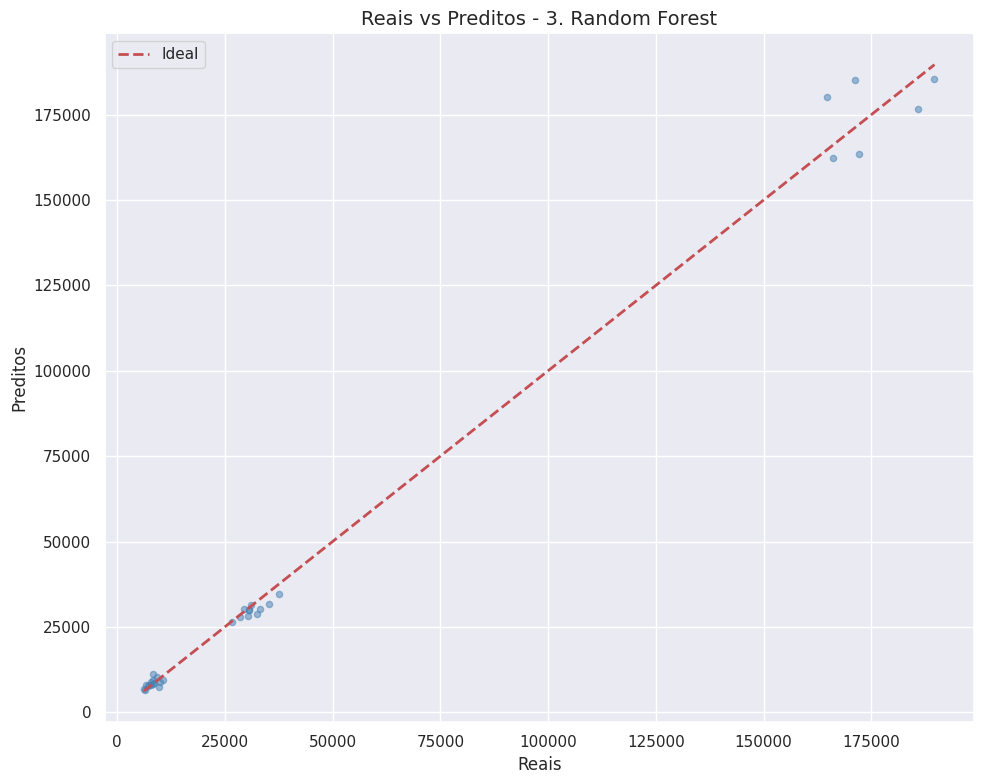

Melhor modelo: 3. Random Forest


In [17]:
best = df_m.loc[df_m['R2'].idxmax(),'Modelo']
preds = resultados[best]['preds']
plt.figure(figsize=(10,8))
plt.scatter(y_test,preds,alpha=0.5,color='steelblue',s=20)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2,label='Ideal')
plt.xlabel('Reais')
plt.ylabel('Preditos')
plt.title(f'Reais vs Preditos - {best}',fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()
print(f'Melhor modelo: {best}')

## 6. Conclusoes, Pontos Fortes e Limitacoes

### Achados da EDA
- O dataset possui multiplas culturas com padroes de rendimento bem distintos.
- A variavel Crop e o principal determinante do Yield.
- As variaveis climaticas apresentam correlacao moderada entre si.

### Achados da Clusterizacao
- K-Means com K=4 agrupou as culturas em segmentos coerentes.
- Outliers detectados pelo IQR representam condicoes climaticas extremas.

### Achados dos Modelos Preditivos
- Random Forest e Gradient Boosting tenderam a ser os melhores modelos.
- Regressao Linear foi inferior por nao capturar relacoes nao-lineares.
- SVR se mostrou competitivo apos normalizacao.

### Pontos Fortes
- Pipeline completo: EDA -> Clusterizacao -> Modelagem -> Avaliacao
- 5 algoritmos com metricas multiplas (MAE, RMSE, R2)
- Normalizacao correta (fit apenas no treino)

### Limitacoes
- Sem hyperparameter tuning
- Label Encoding pode introduzir relacao ordinal falsa
- Dataset sem dimensao temporal